# Lab 6: Gaussian Processes - Modeling and Predicting CO2 measurements 

The goals of this lab are:
* Practice using Gaussian processes
* Compare the use of different kernels
* Model CO2 measurements in the atmosphere and make predictions on the CO2 levels in the future

In this lab, we  will be using data from the the Mauna Loa Observatory, which has been making CO2 measurements of the atmopshere on top of Maunaloa since the late 1950's. It has one of the longest consistent set of measurements of CO2 measurements ever made. It is one of the sources of data used to model climate change. More information on the measurements can be found at: https://www.esrl.noaa.gov/gmd/ccgg/about/co2_measurements.html


Created by: Tuan Do

Last modified: Tuan Do

In [18]:
# imports here
import numpy as np
import pandas as pd
import pylab as plt

import matplotlib
font = {        'size'   : 20}
matplotlib.rc('font', **font)

## Part 1 Big Picture 

Using the CO2 measurements that have been made in the past, we want to predict CO2 measurements in the future as well as the uncertainty in the prediction. We also want to differentiate between seasonal variability from long term trends in the data.

We have two major questions to address in this lab:
1. **How far into the future can we reliably predict the CO2 level of the atmosphere using Gaussian Processes?**
2. **Did the CO2 level rise slow due to the global COVID19 pandemic?**

## Part 2 Get the data

The Mauna Loa Observatory makes their data downloadable here: https://www.esrl.noaa.gov/gmd/ccgg/trends/data.html

We've already downloaded the monthly averaged data into your Lab 6 directory. Load it using the following code.

We will use two of the columns for our work: ``decimal date`` and ``average``, which contains the decimal year for the time and the monthly averaged CO2 concentration in parts per million molecules. 

In [19]:
# load the data
tab = pd.read_csv('co2_mm_mlo.csv',comment='#')

## Part 3 Explore the data

## Question 1
(3 pts)

**Check the shape, and head, plot, visualize, and have a look at the data with whatever ways you think will help your task. What's the time span of the dataset? Etc. Comment throughout on observations.**

# Answer
We have CO2 level records from 1958 to 2024. Average is probably some measure of CO_2 level. From the year-Avearge plot, the CO2 level seems to accelerate.

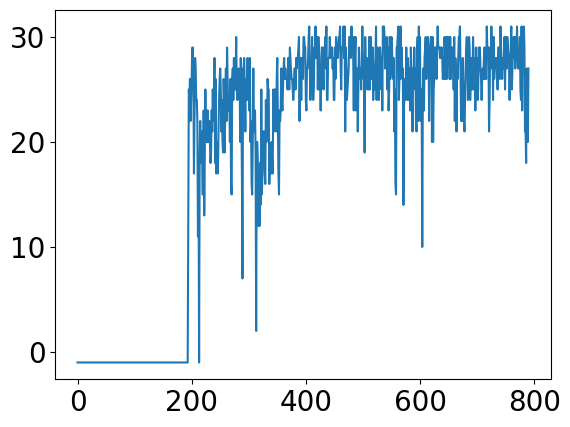

In [20]:
plt.plot(tab.ndays)

In [21]:
# code here
tab.head()

,year,month,decimal date,average,deseasonalized,ndays,sdev,unc
0,1958,3,1958.2027,315.70,314.43,-1,-9.99,-0.99
1,1958,4,1958.2877,317.45,315.16,-1,-9.99,-0.99
2,1958,5,1958.3699,317.51,314.71,-1,-9.99,-0.99
3,1958,6,1958.4548,317.24,315.14,-1,-9.99,-0.99
4,1958,7,1958.5370,315.86,315.18,-1,-9.99,-0.99


In [22]:
tab.describe()

,year,month,decimal date,average,deseasonalized,ndays,sdev,unc
count,791.000000,791.000000,791.000000,791.000000,791.000000,791.000000,791.000000,791.000000
mean,1990.624526,6.505689,1991.124379,358.783704,358.783198,19.030341,-2.098521,-0.098647
std,19.041177,3.452705,19.041344,31.411617,31.362066,12.009662,4.535248,0.512949
min,1958.000000,1.000000,1958.202700,312.430000,314.430000,-1.000000,-9.990000,-0.990000
25%,1974.000000,4.000000,1974.666650,330.230000,330.515000,10.500000,0.165000,0.065000
50%,1991.000000,7.000000,1991.125000,354.930000,355.260000,25.000000,0.400000,0.150000
75%,2007.000000,9.500000,2007.583350,384.280000,384.155000,28.000000,0.565000,0.210000
max,2024.000000,12.000000,2024.041700,424.000000,422.560000,31.000000,1.310000,0.580000


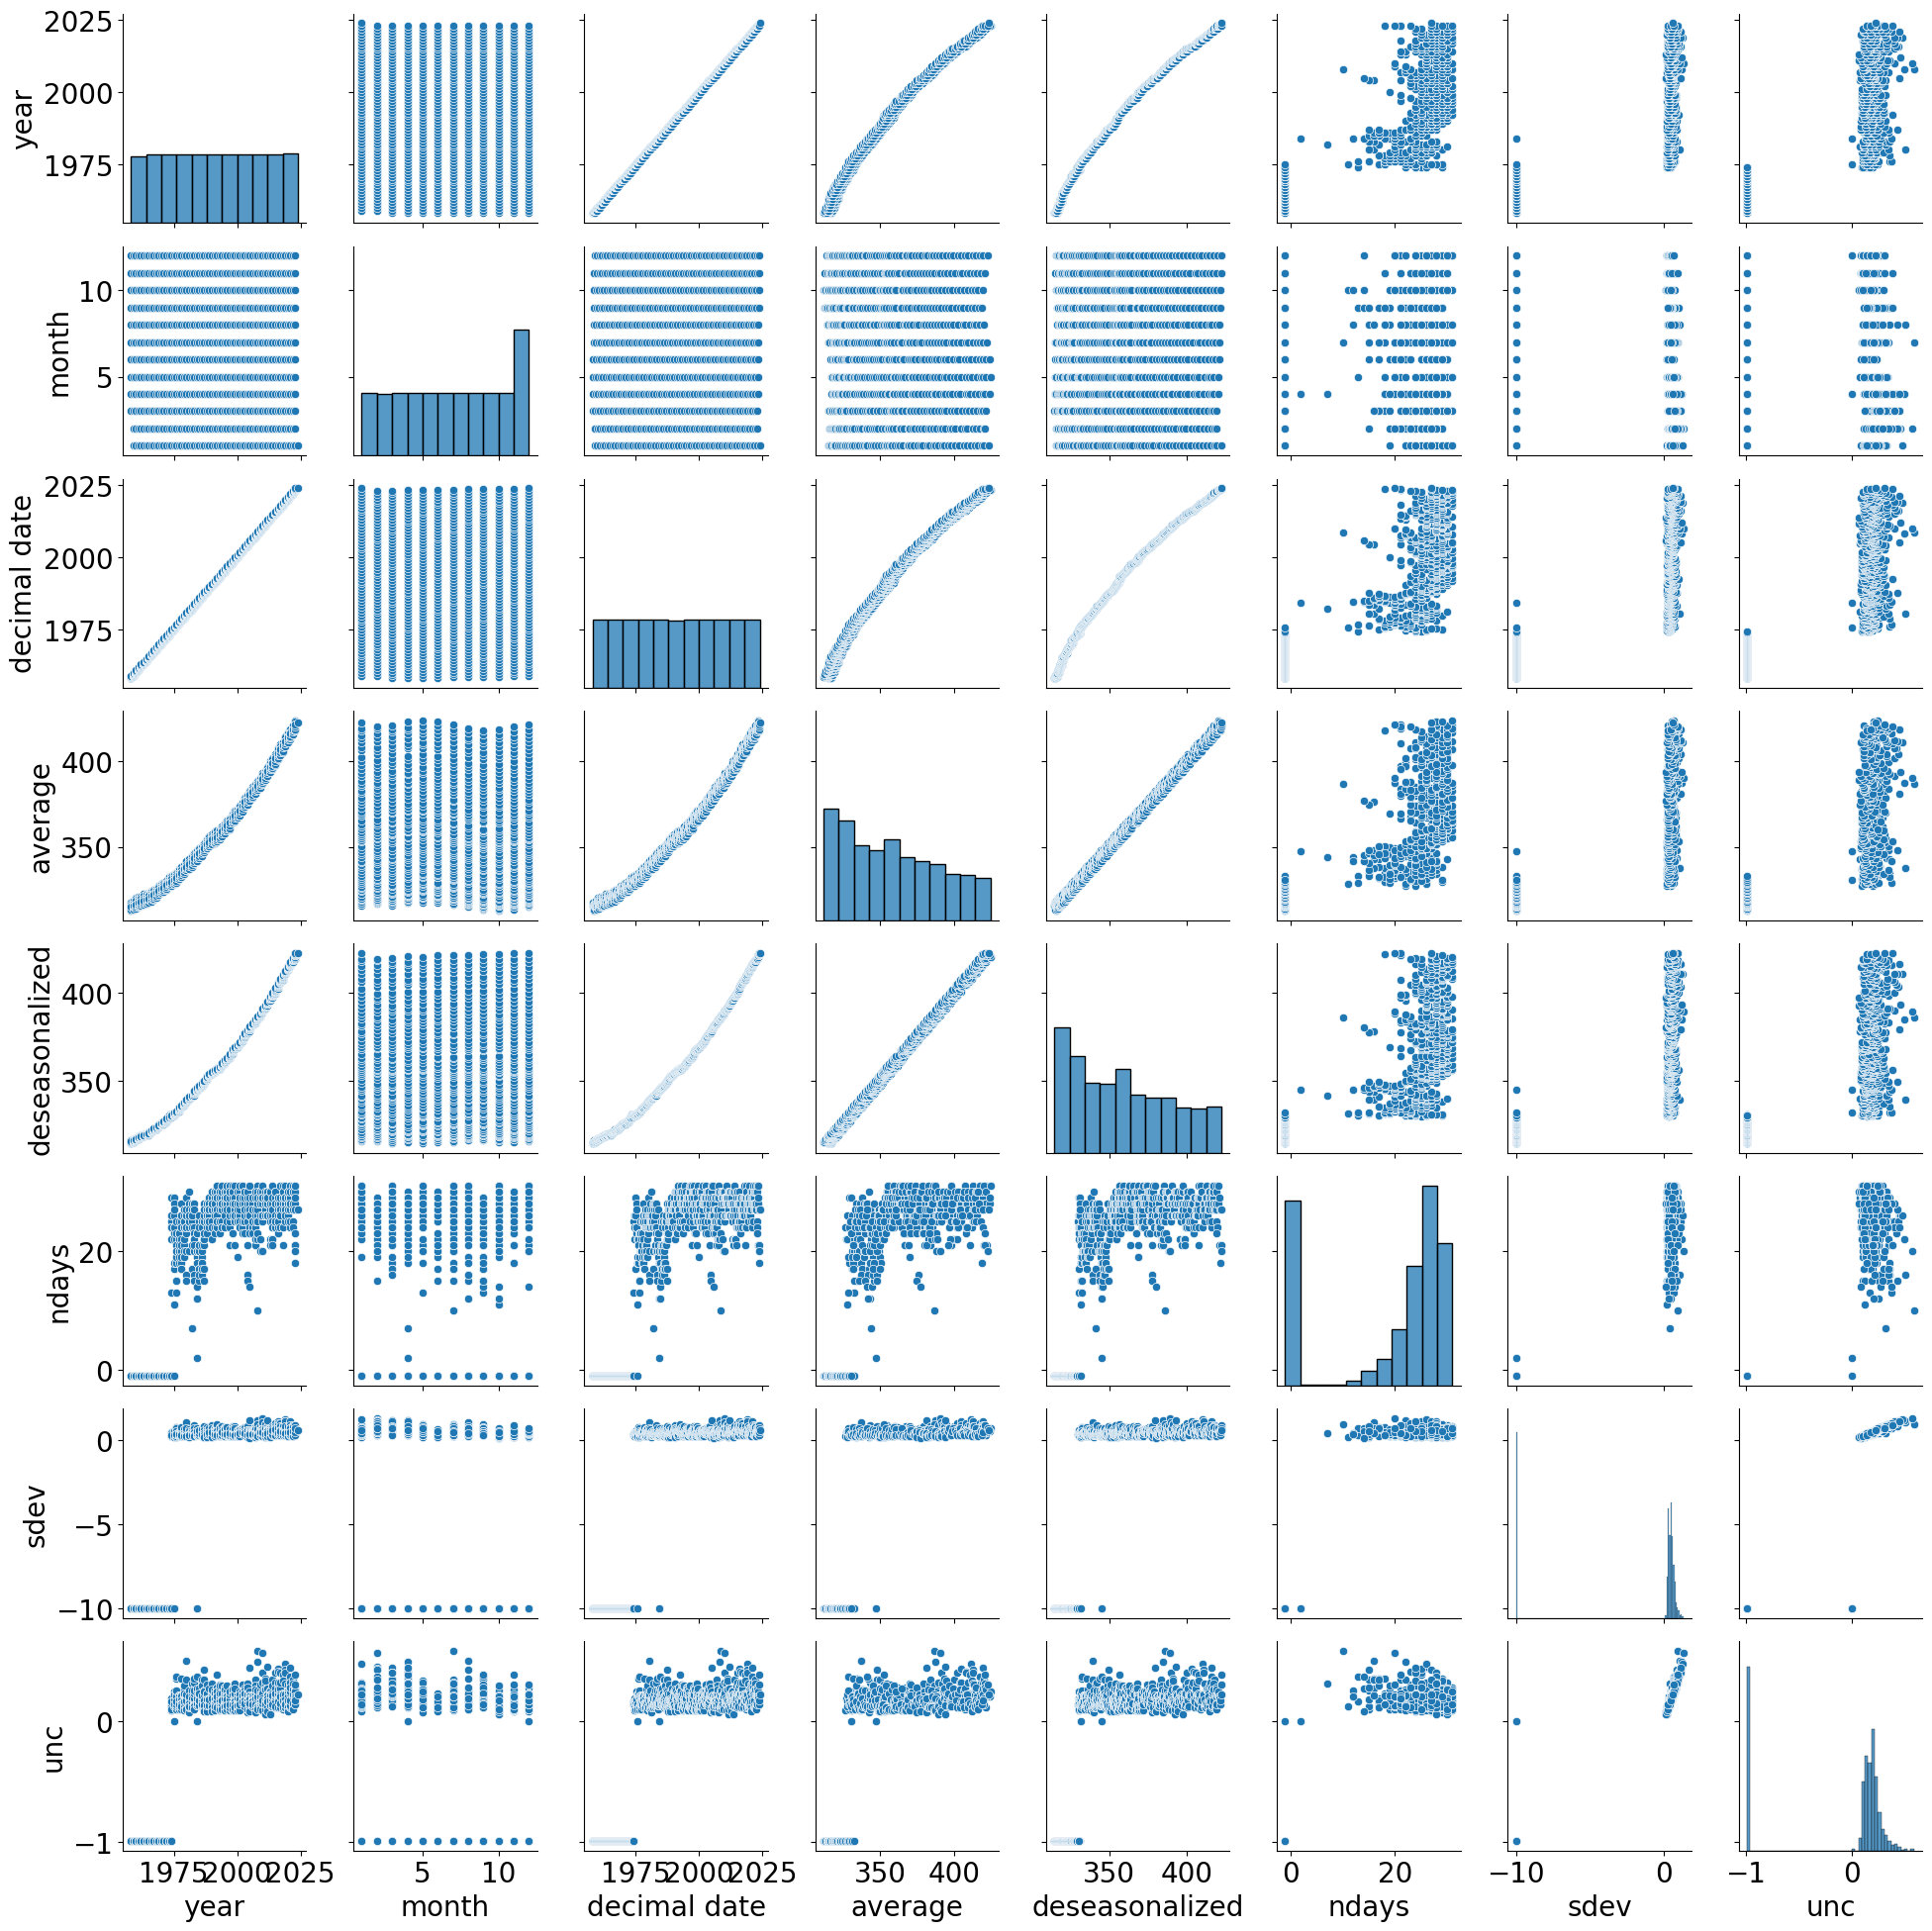

In [23]:
import seaborn as sns
sns.pairplot(tab)

## Part 4 Prepare Data

## Question 2
(2 pts)

**Are there outliers in the dataset? If so remove them and then create your feature (the decimal years) and target arrays (the average CO2 concentration). Use only the data from 1958 to 2010 for training. Make a separate array with the data from the beginning of 2011 to the end of 2019 for testing.**


# Answer
The following codes removes the data points with negative sdev and then truncated the data points within the \pm 2.5 sigma range of sdev values and stored the value in newnew_tab.

In [24]:
# code here
tab.isna().sum()

year              0
month             0
decimal date      0
average           0
deseasonalized    0
ndays             0
sdev              0
unc               0
dtype: int64

In [25]:
tab.shape

(791, 8)

In [88]:
new_tab = tab.loc[tab.sdev > -1]
ind = tab.loc[tab.sdev > -1]
year = ind.year
avg = ind.average
arr = np.array([year, avg]).transpose()
arr.shape = (ind.shape[0],2)
arr
    

array([[1974.  ,  333.18],
       [1974.  ,  332.2 ],
       [1974.  ,  331.07],
       ...,
       [2023.  ,  420.46],
       [2023.  ,  421.86],
       [2024.  ,  422.8 ]], shape=(595, 2))

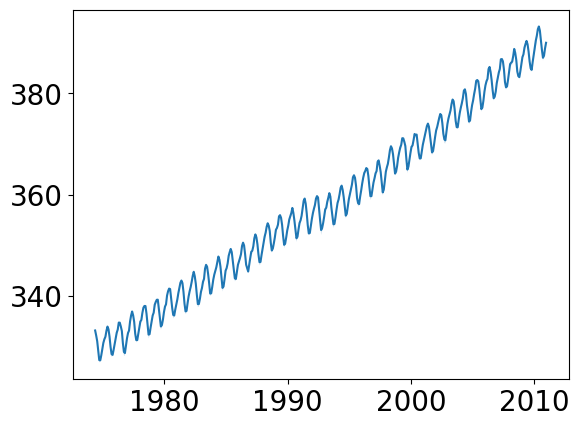

In [89]:
plt.plot(new_tab.loc[new_tab.year < 2011]['decimal date'], new_tab.loc[new_tab.year < 2011].average)
plt.fill_between(new_tab.loc[new_tab.year < 2011]['decimal date'], new_tab.loc[new_tab.year < 2011].average,new_tab.loc[new_tab.year < 2011].average -new_tab.loc[new_tab.year < 2011].sdev, alpha=0.2)

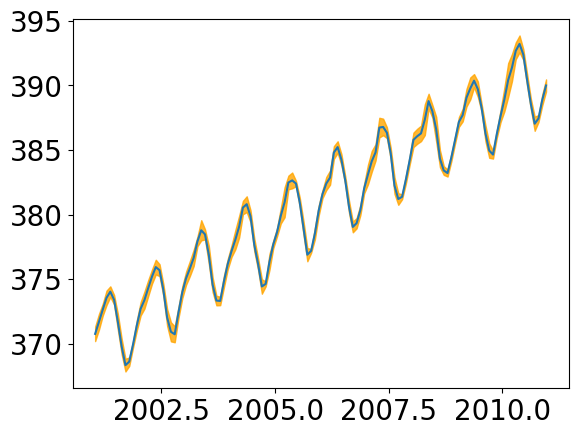

In [28]:
tab2 = new_tab.loc[(new_tab.year < 2011) & (new_tab.year > 2000) ]
plt.plot(tab2['decimal date'], tab2.average)
plt.fill_between(tab2['decimal date'], tab2.average + tab2.sdev, tab2.average - tab2.sdev, color= 'orange', alpha=0.8)

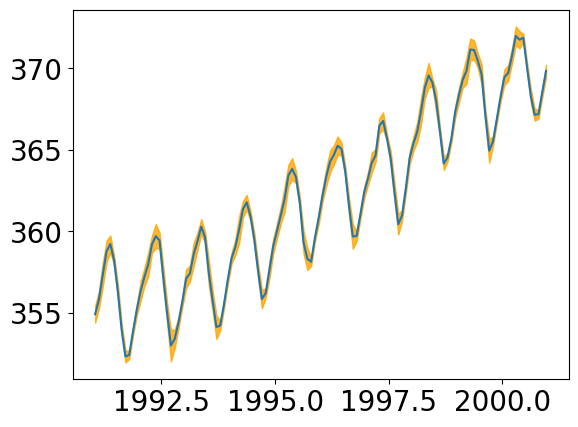

In [29]:
tab2 = new_tab.loc[(new_tab.year < 2001) & (new_tab.year > 1990) ]
plt.plot(tab2['decimal date'], tab2.average)
plt.fill_between(tab2['decimal date'], tab2.average + tab2.sdev, tab2.average - tab2.sdev, color= 'orange', alpha=0.8)

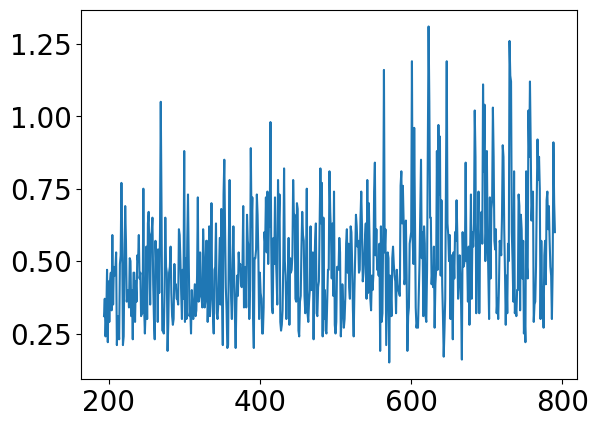

In [30]:
plt.plot(new_tab.sdev)

In [31]:
m, s = new_tab.sdev.mean(), new_tab.sdev.std()
newnew_tab = new_tab.loc[(new_tab.sdev < m+ 2.5*s) & (new_tab.sdev > m- 2.5*s)]
new_tab.shape, newnew_tab.shape

((595, 8), (580, 8))

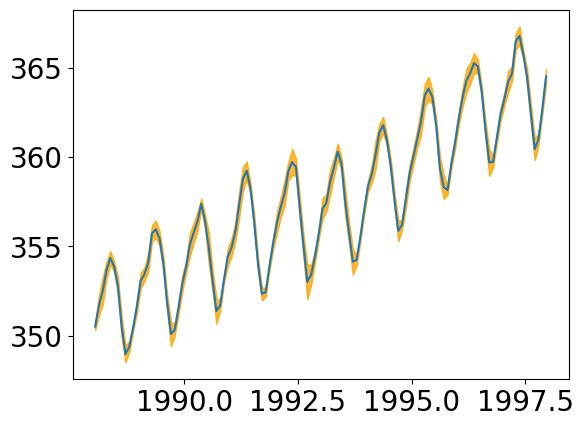

In [32]:
ntab1 = newnew_tab.loc[(newnew_tab.year < 1998) & (newnew_tab.year > 1987) ]
plt.plot(ntab1['decimal date'], ntab1.average)
plt.fill_between(ntab1['decimal date'], ntab1.average + ntab1.sdev, ntab1.average - ntab1.sdev, color= 'orange', alpha=0.8)

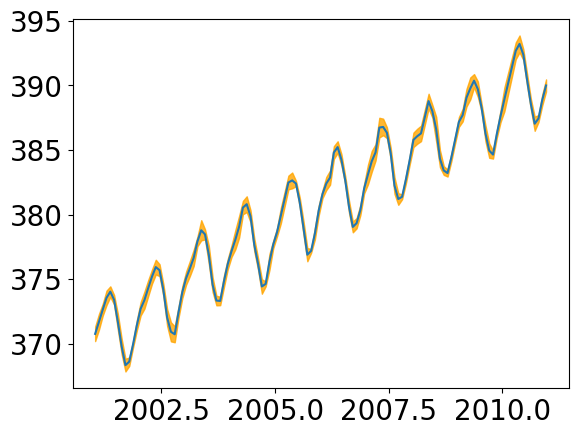

In [33]:
tab2 = newnew_tab.loc[(newnew_tab.year < 2011) & (new_tab.year > 2000) ]
plt.plot(tab2['decimal date'], tab2.average)
plt.fill_between(tab2['decimal date'], tab2.average + tab2.sdev, tab2.average - tab2.sdev, color= 'orange', alpha=0.8)

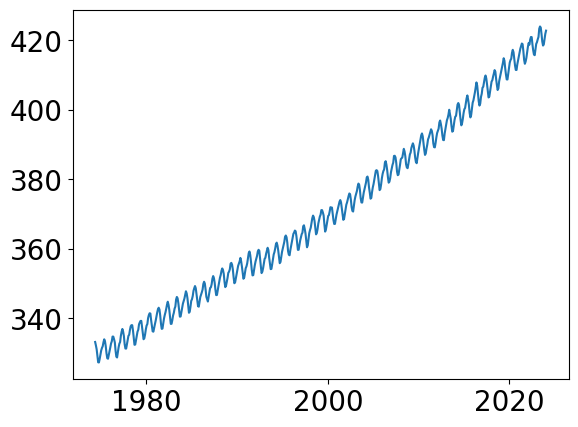

In [93]:
year = newnew_tab['decimal date']
avg = newnew_tab.average
arr = np.array([year, avg]).transpose()
arr.shape = (newnew_tab.shape[0],2)
plt.plot(year,avg)

## Part 5 Select model and train


In examining the model, we can see that there is a long term trend but also some periodic variations. We can use a combination of kernels to model the curve. 

Some helpful references for using Gaussian Processes with Scikit Learn are here:
* https://scikit-learn.org/stable/modules/generated/sklearn.gaussian_process.GaussianProcessRegressor.htm
* https://scikit-learn.org/stable/modules/gaussian_process.html

### Part 5.1 Practice with Kernels

To understand how to use Gaussian processes, we will practice with start by an example of using kernels in Scikit Learn. 

We will start with the Radial Basis Kernel (also known as the squared exponential kernel). This kernel corresponds to a basis set of Gaussians. It is often used to fit time series data that has correlation over some length scale. 

Start by reading about the RBF kernel in Scikit Learn: https://scikit-learn.org/stable/modules/generated/sklearn.gaussian_process.kernels.RBF.html

Below is some code used to initialize a Gaussian Process regression model and the RBF kernel. Before fitting the data, we can use this model to sample from the prior space of functions that are defined by the kernel. Often it is useful to see the shape and form of the functions that it can model. This will help you get a since of what kernels might be useful for modeling your data.

In [35]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import (RBF, Matern, RationalQuadratic,
                                              ExpSineSquared, DotProduct,
                                              ConstantKernel, WhiteKernel)

Text(0.5, 0, 'Years')

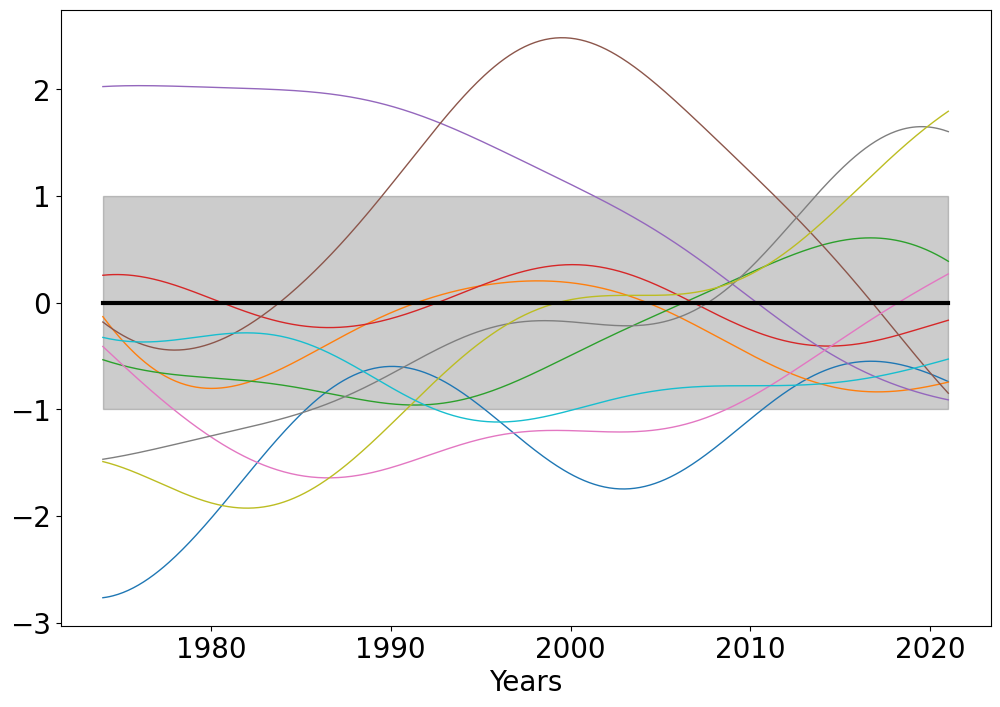

In [36]:
kernel = 1.0 * RBF(length_scale=10.0, length_scale_bounds=(1e-1, 10.0))

gp = GaussianProcessRegressor(kernel=kernel)
plt.figure(figsize=(12,8))
X_ = np.linspace(1974, 2021, 500)
y_mean, y_std = gp.predict(X_[:, np.newaxis], return_std=True)
plt.plot(X_, y_mean, 'k', lw=3, zorder=9)
plt.fill_between(X_, y_mean - y_std, y_mean + y_std,
                 alpha=0.2, color='k')
y_samples = gp.sample_y(X_[:, np.newaxis], 10)
plt.plot(X_, y_samples, lw=1)
plt.xlabel('Years')

Text(0.5, 0, 'Years')

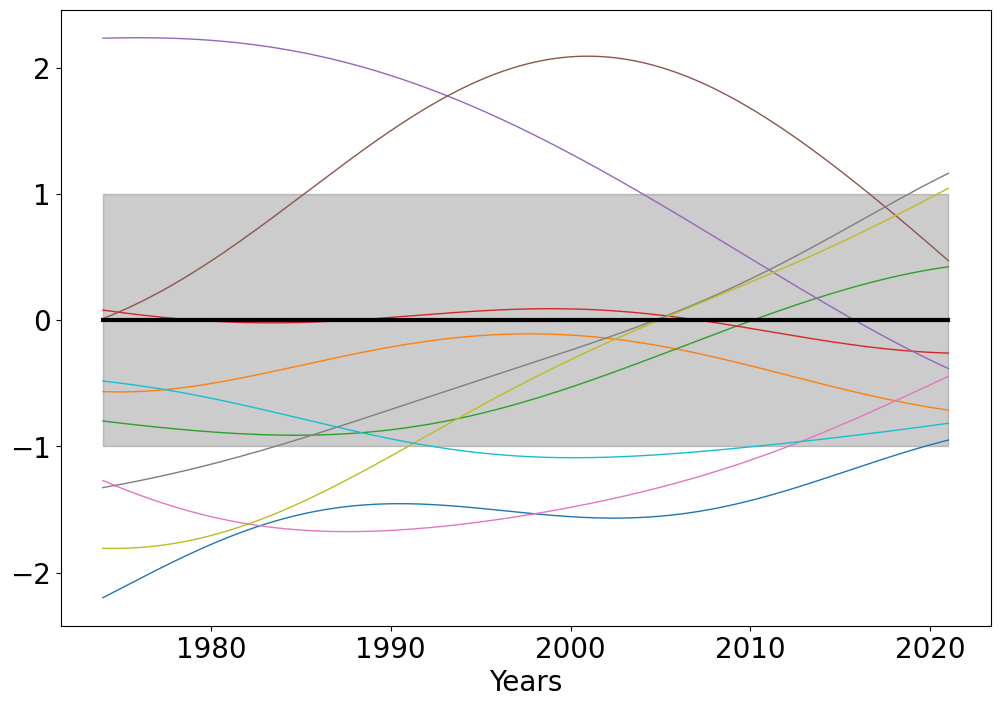

In [37]:
kernel = 1.0 * RBF(length_scale=20.0, length_scale_bounds=(1e-1, 10.0))

gp = GaussianProcessRegressor(kernel=kernel)
plt.figure(figsize=(12,8))
X_ = np.linspace(1974, 2021, 500)
y_mean, y_std = gp.predict(X_[:, np.newaxis], return_std=True)
plt.plot(X_, y_mean, 'k', lw=3, zorder=9)
plt.fill_between(X_, y_mean - y_std, y_mean + y_std,
                 alpha=0.2, color='k')
y_samples = gp.sample_y(X_[:, np.newaxis], 10)
plt.plot(X_, y_samples, lw=1)
plt.xlabel('Years')

## Question 3
(3 pts)

**In the example code above, what are the hyperparameters of the ``RBF`` kernel? Describe the effect of those parameters.**

# your answer here

The hyperparameters are length_scale=10.0, length_scale_bounds=(1e-1, 10.0).  

The length_scale is the width of the kernel (two-point function or green's function).  Smaller length_scale tends to overfit to the known data, while the broader length are flexible.

GaussianProcessRegressor tunes the length_scale to find the optimal function output (that of the highest posterior).  The length_scale_bounds provides the lower and upper bound of the length_scale as it is tuned.  The larger this range, the more varied basis functions (in terms of their spread) we have.

## Question 4
(6 pts)

**In a similar way as the example above, examine and plot some samples from the ``ExpSineSquared`` and ``WhiteKernel``. What are the hyperparameters of these kernels? Describe qualitatitvely what the samples from the prior look like for these kernels.**

Text(0.5, 0, 'Years')

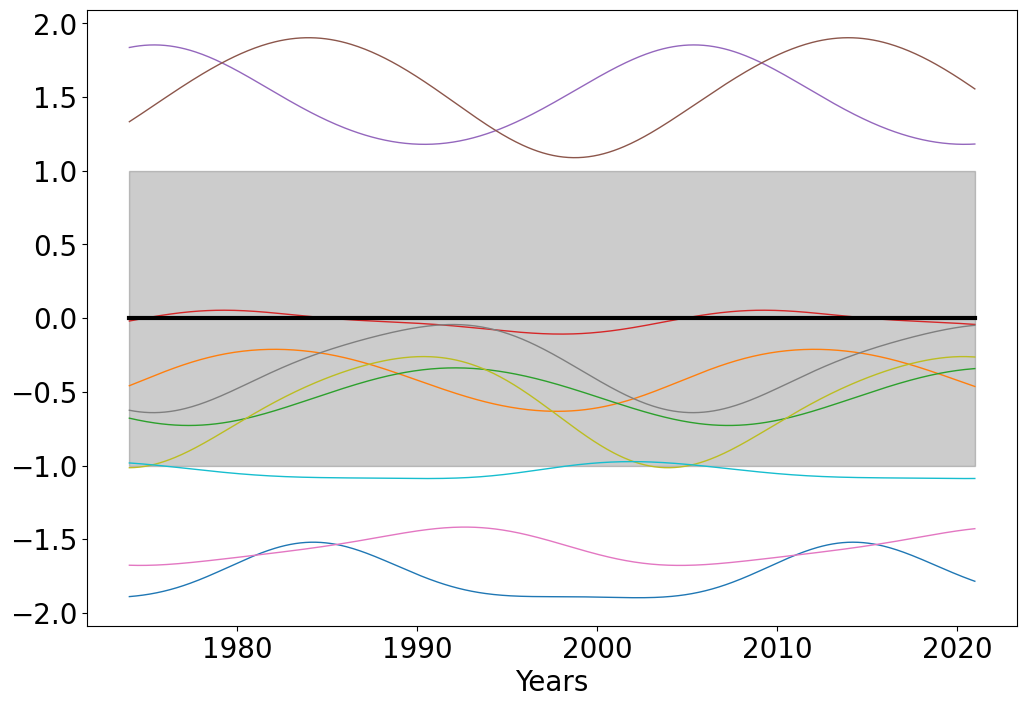

In [38]:
# code here
from sklearn.gaussian_process.kernels import ExpSineSquared

# kernel = 1.0 * RBF(length_scale=20.0, length_scale_bounds=(1e-1, 10.0))
kernel = ExpSineSquared(length_scale = 5.0, periodicity = 30.0, length_scale_bounds=(1e-05, 100000.0), periodicity_bounds=(1e-05, 100000.0))

gp = GaussianProcessRegressor(kernel=kernel)
plt.figure(figsize=(12,8))
X_ = np.linspace(1974, 2021, 500)
y_mean, y_std = gp.predict(X_[:, np.newaxis], return_std=True)
plt.plot(X_, y_mean, 'k', lw=3, zorder=9)
plt.fill_between(X_, y_mean - y_std, y_mean + y_std,
                 alpha=0.2, color='k')
y_samples = gp.sample_y(X_[:, np.newaxis], 10)
plt.plot(X_, y_samples, lw=1)
plt.xlabel('Years')

Text(0.5, 0, 'Years')

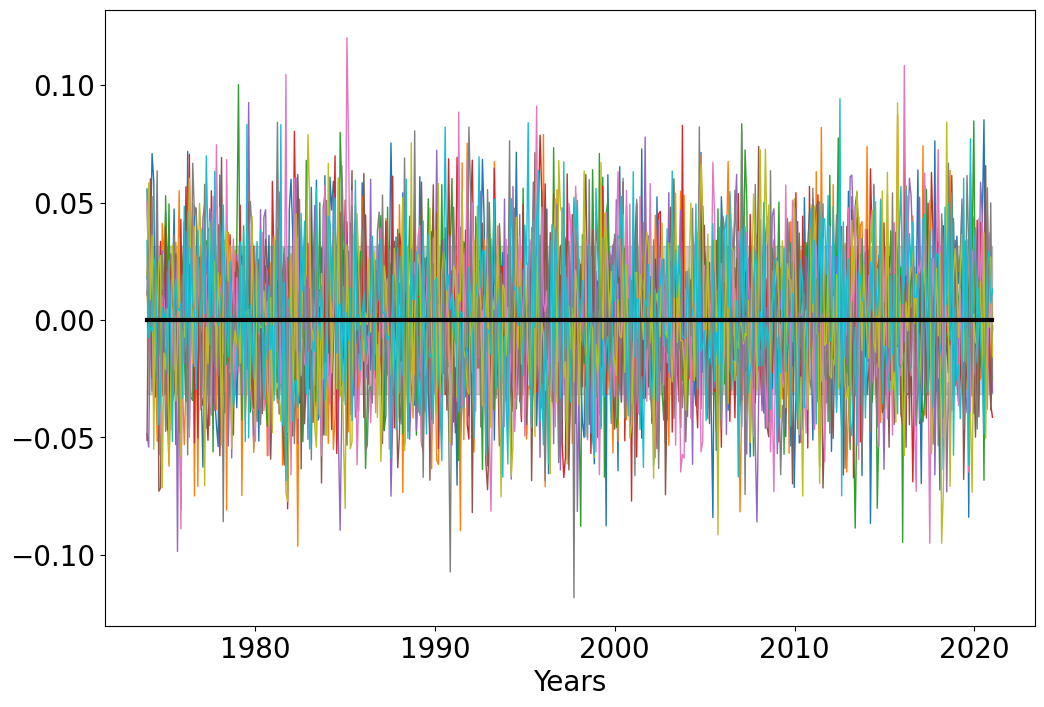

In [39]:
from sklearn.gaussian_process.kernels import WhiteKernel
kernel = WhiteKernel(noise_level=0.001, noise_level_bounds=(1e-05, 100000.0))

gp = GaussianProcessRegressor(kernel=kernel)
plt.figure(figsize=(12,8))
X_ = np.linspace(1974, 2021, 500)
y_mean, y_std = gp.predict(X_[:, np.newaxis], return_std=True)
plt.plot(X_, y_mean, 'k', lw=3, zorder=9)
plt.fill_between(X_, y_mean - y_std, y_mean + y_std,
                 alpha=0.2, color='k')
y_samples = gp.sample_y(X_[:, np.newaxis], 10)
plt.plot(X_, y_samples, lw=1)
plt.xlabel('Years')

# Answers:

ExpSineSquared's hyperparameters: length_scale=1.0, periodicity=1.0, length_scale_bounds=(1e-05, 100000.0), periodicity_bounds=(1e-05, 100000.0)

WhiteKernel's hyperparameters: noise_level=1.0, noise_level_bounds=(1e-05, 100000.0)
k(x,y) = noise_level, if x=y; 0, otherwise.

### Part 5.2 Put together a Gaussian Process Model

One of the great propertiers of Gaussian Processes is that you can simply add kernels together to make more complicated models. 


We'll start off first with just the ``RBF`` kernel to fit the long term trends. Below is some example code to show how to do it with Scikit Learn.


In [101]:
k1 = 66.0**2 * RBF(length_scale=67.0)  # long term smooth rising trend

kernel_gpml = k1    # here we have just 1 kernel

gp = GaussianProcessRegressor(kernel=kernel_gpml, alpha=0.01,normalize_y=True)

# NOTE: running the .fit method will fit for the hyper parameters of the kernel. Fitting might take a while
X = np.array(newnew_tab['decimal date']).reshape(-1, 1)
y = np.array(newnew_tab.average)
gp.fit(X,y)

print("GPML kernel: %s" % gp.kernel_)
print("Log-marginal-likelihood: %.3f"
      % gp.log_marginal_likelihood(gp.kernel_.theta))

GPML kernel: 2.66**2 * RBF(length_scale=38.4)
Log-marginal-likelihood: 574.643


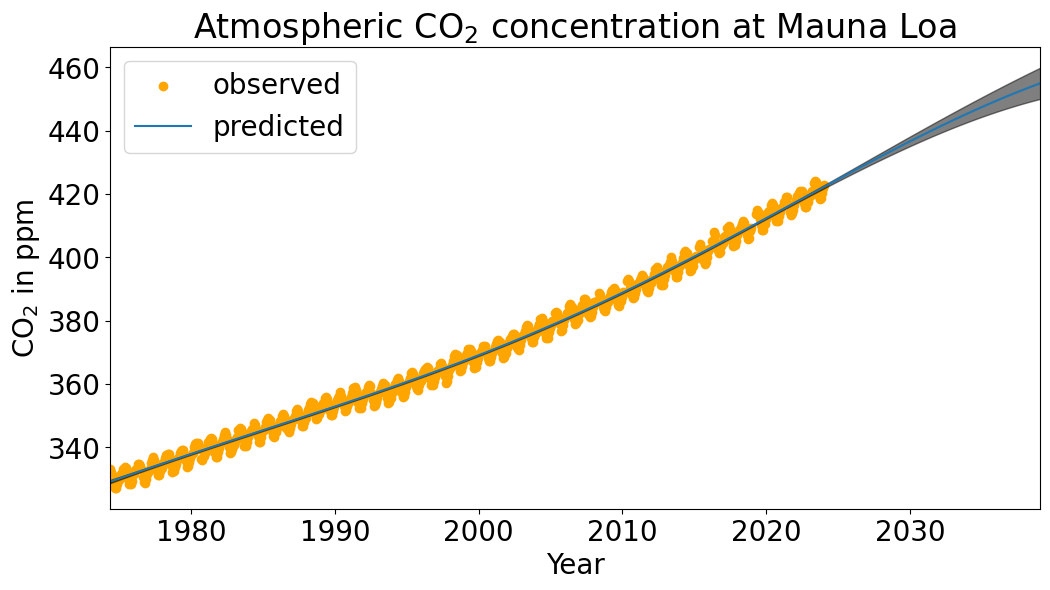

In [102]:
# plot the predictions

X_ = np.linspace(X.min(), X.max() + 15, 1000)[:, np.newaxis] # predict 10 years into the future
y_pred, y_std = gp.predict(X_, return_std=True)

# Illustration
plt.figure(figsize=(12,6))
plt.scatter(X, y, c='orange',label='observed')
plt.plot(X_, y_pred,label='predicted')
plt.fill_between(X_[:, 0], y_pred - y_std, y_pred + y_std,
                 alpha=0.5, color='k')
plt.xlim(X_.min(), X_.max())
plt.xlabel("Year")
plt.ylabel(r"CO$_2$ in ppm")
plt.title(r"Atmospheric CO$_2$ concentration at Mauna Loa")
plt.legend()


Similarly, we can use instead the periodic kernel ``ExpSineSquared`` to model the periodic behavoir of the curve.

In [103]:
k2 = ExpSineSquared(length_scale=1.0, periodicity=1.0,
                     periodicity_bounds="fixed")
kernel_gpml = k2    # here we have just 1 kernel

gp = GaussianProcessRegressor(kernel=kernel_gpml, alpha=0.01,normalize_y=True)

# NOTE: running the .fit method will fit for the hyper parameters of the kernel. Fitting might take a while
gp.fit(X,y)


print("GPML kernel: %s" % gp.kernel_)
print("Log-marginal-likelihood: %.3f"
      % gp.log_marginal_likelihood(gp.kernel_.theta))

GPML kernel: ExpSineSquared(length_scale=2.2, periodicity=1)
Log-marginal-likelihood: -28069.099


GPML kernel: ExpSineSquared(length_scale=2.2, periodicity=1)
Log-marginal-likelihood: -28069.099


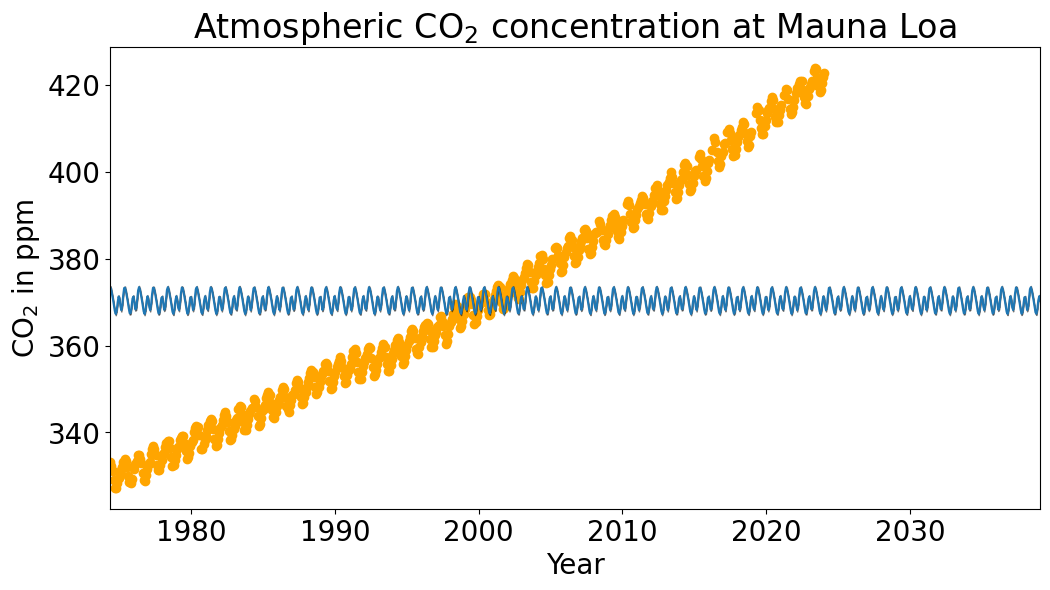

In [104]:
k2 = ExpSineSquared(length_scale=1.0, periodicity=1.0,
                     periodicity_bounds="fixed")
kernel_gpml = k2    # here we have just 1 kernel

gp = GaussianProcessRegressor(kernel=kernel_gpml, alpha=0.01,normalize_y=True)

# NOTE: running the .fit method will fit for the hyper parameters of the kernel. Fitting might take a while
gp.fit(X,y)

# plot the predictions

X_ = np.linspace(X.min(), X.max() + 15, 1000)[:, np.newaxis] # predict 10 years into the future
y_pred, y_std = gp.predict(X_, return_std=True)

# Illustration
plt.figure(figsize=(12,6))
plt.scatter(X, y, c='orange')
plt.plot(X_, y_pred)
plt.fill_between(X_[:, 0], y_pred - y_std, y_pred + y_std,
                 alpha=0.5, color='k')
plt.xlim(X_.min(), X_.max())
plt.xlabel("Year")
plt.ylabel(r"CO$_2$ in ppm")
plt.title(r"Atmospheric CO$_2$ concentration at Mauna Loa")

print("GPML kernel: %s" % gp.kernel_)
print("Log-marginal-likelihood: %.3f"
      % gp.log_marginal_likelihood(gp.kernel_.theta))

## Question 5
(4 pts)

**Now create a new kernel by adding the ``RBF`` and the ``ExpSineSquared`` kernels together. Make a plot of the fit and the prediction. Plot the test data that you saved from 2011 to 2019. Describe the model performance.**

GPML kernel: 2.89**2 * RBF(length_scale=39.9) + ExpSineSquared(length_scale=5.32, periodicity=1)
Log-marginal-likelihood: 757.262


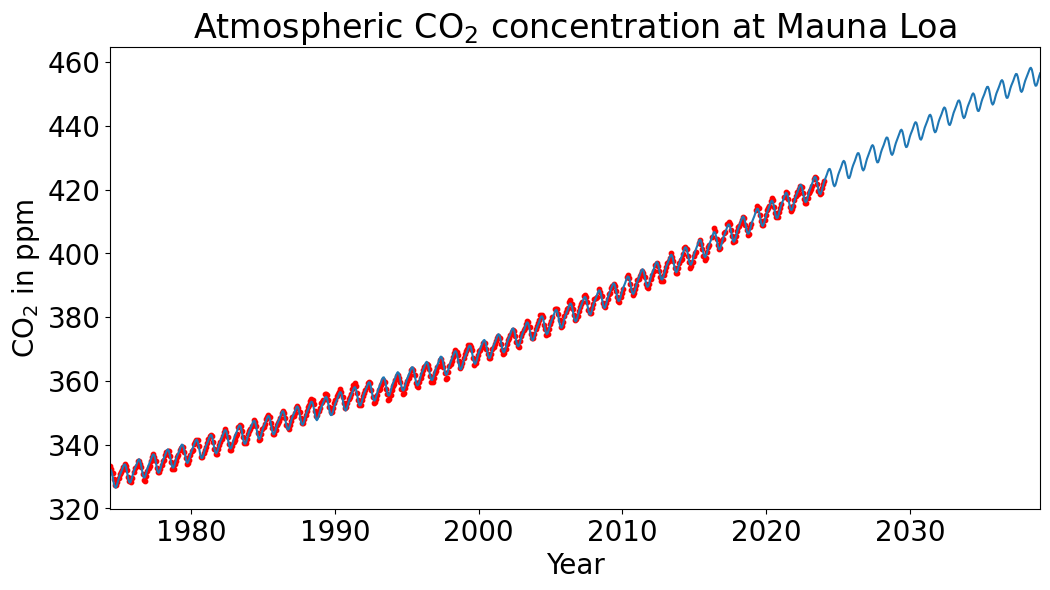

In [109]:
# code here

k1 = 66.0**2 * RBF(length_scale=67.0)  # long term smooth rising trend

k2 = ExpSineSquared(length_scale=1, periodicity=1, periodicity_bounds="fixed")
#k2 = ExpSineSquared(length_scale=1, periodicity=2)
kernel_gpml = k1 + k2    # here we have just 1 kernel

gp = GaussianProcessRegressor(kernel=kernel_gpml, alpha=0.01,normalize_y=True)

# NOTE: running the .fit method will fit for the hyper parameters of the kernel. Fitting might take a while
gp.fit(X,y)

# plot the predictions

X_ = np.linspace(X.min(), X.max() + 15, 1000)[:, np.newaxis] # predict 10 years into the future
y_pred, y_std = gp.predict(X_, return_std=True)

# Illustration
plt.figure(figsize=(12,6))
plt.scatter(X, y, c='red',s=10)
plt.plot(X_, y_pred)
# plt.fill_between(X_[:, 0], y_pred - y_std, y_pred + y_std,
                 #alpha=0.5, color='k')
plt.xlim(X_.min(), X_.max())
plt.xlabel("Year")
plt.ylabel(r"CO$_2$ in ppm")
plt.title(r"Atmospheric CO$_2$ concentration at Mauna Loa")

print("GPML kernel: %s" % gp.kernel_)
print("Log-marginal-likelihood: %.3f"
      % gp.log_marginal_likelihood(gp.kernel_.theta))

## Part 6 Fine tune model

While the major properties of the CO2 curve was represented by our two kernel model, we can do better by allowing for some variations in the long term trend, variations in the periodic signal, and allowing for noise. 

We can do this by adjusting and including more kernels. 

## Question 6
(6 pts)

**Create a kernel the combination of four components:**

* The same ``RBF`` kernel as in Part 5
* Modify the periodic ``ExpSineSquared`` kernel in Part 5 by **multipyling** it with another ``RBF`` kernel to allow the periodic signal to vary slightly. 
* Add a ``RationalQuadratic`` kernel to account for medium term irregularies
* Add a ``WhiteKernel`` to account for white noise (Gaussian noise) in the modeling
* Hint: if you need help with this, see https://scikit-learn.org/stable/auto_examples/gaussian_process/plot_gpr_co2.html 

**Fit the data from 1958 to 2010, and the fit the GP model**

In [111]:
# code here
# code here

k1 = 66.0**2 * RBF(length_scale=67.0)  # long term smooth rising trend

k2 = ExpSineSquared(length_scale=1, periodicity=1, periodicity_bounds="fixed")
k3 = 1.0**2 * RBF(length_scale=10.0)

k4 = WhiteKernel(noise_level=0.001, noise_level_bounds=(1e-05, 100000.0))

kernel_gpml = k1 + k2*k3 + k4   # here we have just 1 kernel

gp = GaussianProcessRegressor(kernel=kernel_gpml, alpha=0.01,normalize_y=True)

# NOTE: running the .fit method will fit for the hyper parameters of the kernel. Fitting might take a while

gp.fit(X,y)

print("GPML kernel: %s" % gp.kernel_)
print("Log-marginal-likelihood: %.3f"
      % gp.log_marginal_likelihood(gp.kernel_.theta))

GPML kernel: 2.74**2 * RBF(length_scale=39) + ExpSineSquared(length_scale=2.42, periodicity=1) * 0.228**2 * RBF(length_scale=6.73e+04) + WhiteKernel(noise_level=1e-05)
Log-marginal-likelihood: 757.819


/opt/conda/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


**Plot the data and the predictions. Plot the 2011-2021 data and discuss how well it fits. Compare the prediction to that from Part 5.**

GPML kernel: 2.74**2 * RBF(length_scale=39) + ExpSineSquared(length_scale=2.42, periodicity=1) * 0.228**2 * RBF(length_scale=6.73e+04) + WhiteKernel(noise_level=1e-05)
Log-marginal-likelihood: 757.819


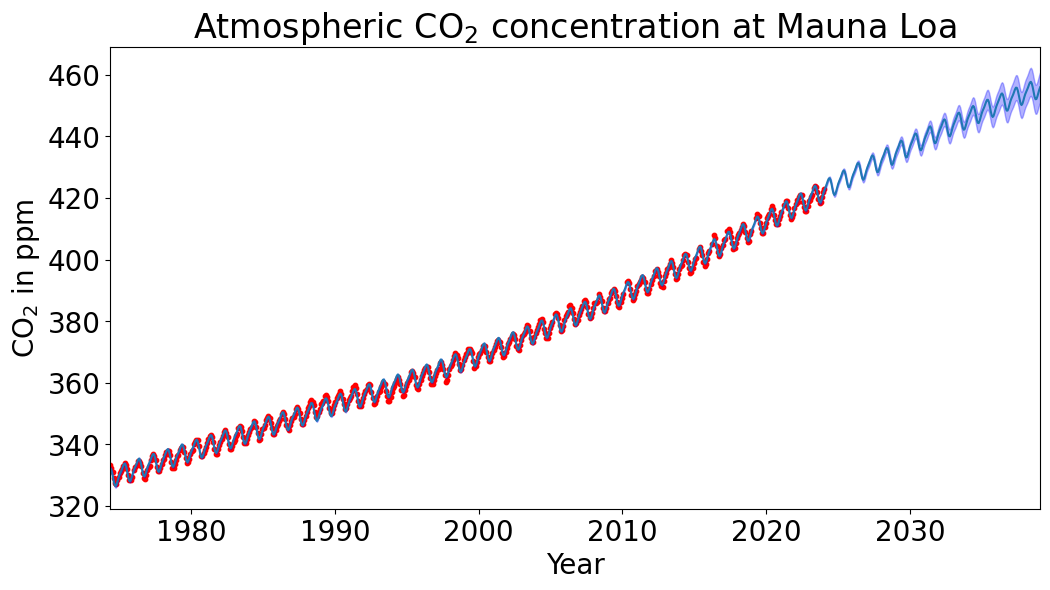

In [116]:
# code here
# plot the predictions

X_ = np.linspace(X.min(), X.max() + 15, 1000)[:, np.newaxis] # predict 10 years into the future
y_pred, y_std = gp.predict(X_, return_std=True)

# Illustration
plt.figure(figsize=(12,6))
plt.scatter(X, y, c='red',s=10)
plt.plot(X_, y_pred)
plt.fill_between(X_[:, 0], y_pred - y_std, y_pred + y_std,
                 alpha=0.3, color='blue')
plt.xlim(X_.min(), X_.max())
plt.xlabel("Year")
plt.ylabel(r"CO$_2$ in ppm")
plt.title(r"Atmospheric CO$_2$ concentration at Mauna Loa")

print("GPML kernel: %s" % gp.kernel_)
print("Log-marginal-likelihood: %.3f"
      % gp.log_marginal_likelihood(gp.kernel_.theta))

## Question 7
(3 pts)

**Explore some variations in the kernels to see if you can get a better prediction**

This model performs really well already.

Raising the noise_level to the white noise doesn't seem to change a lot. (the initialisation becomes redundant.)
Changing the RBF (long-term trend) length_scale doesn't also change a lot (it got optimised, too).



/opt/conda/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__k2__k2__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/opt/conda/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


GPML kernel: 2.74**2 * RBF(length_scale=39) + ExpSineSquared(length_scale=2.42, periodicity=1) * 0.228**2 * RBF(length_scale=1e+05) + WhiteKernel(noise_level=1e-05)
Log-marginal-likelihood: 757.819
GPML kernel: 2.74**2 * RBF(length_scale=39) + ExpSineSquared(length_scale=2.42, periodicity=1) * 0.228**2 * RBF(length_scale=1e+05) + WhiteKernel(noise_level=1e-05)
Log-marginal-likelihood: 757.819


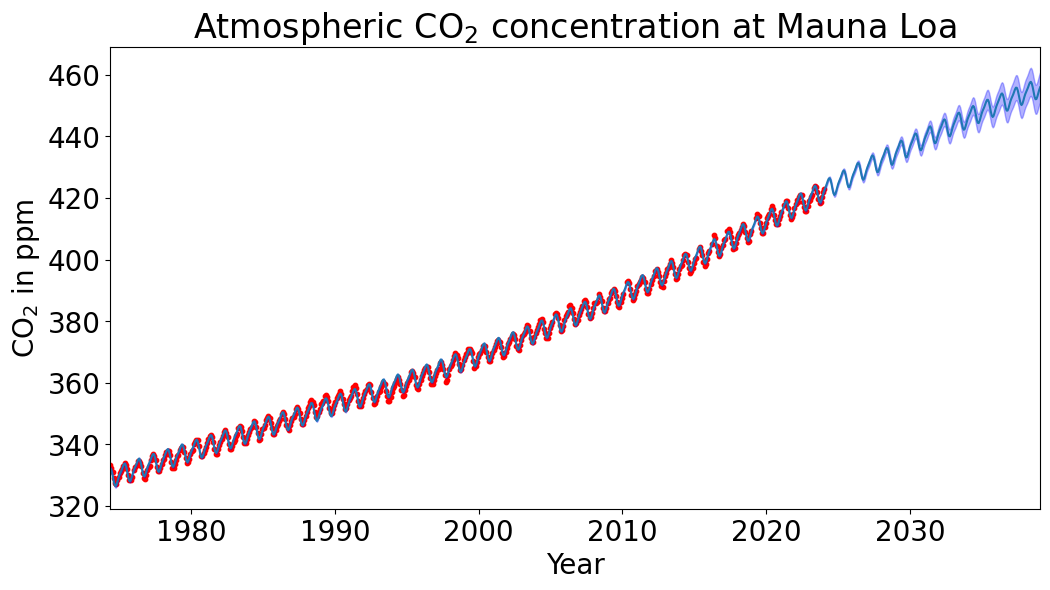

In [132]:
# Raising the noise_level to 0.1
# code here

k1 = 66.0**2 * RBF(length_scale=67.0)  # long term smooth rising trend

k2 = ExpSineSquared(length_scale=1, periodicity=1, periodicity_bounds="fixed")
k3 = 1.0**2 * RBF(length_scale=10.0)

k4 = WhiteKernel(noise_level=0.1, noise_level_bounds=(1e-05, 100000.0))

kernel_gpml = k1 + k2*k3 + k4   # here we have just 1 kernel

gp = GaussianProcessRegressor(kernel=kernel_gpml, alpha=0.01,normalize_y=True)

# NOTE: running the .fit method will fit for the hyper parameters of the kernel. Fitting might take a while
X = np.array(newnew_tab['decimal date']).reshape(-1, 1)
y = np.array(newnew_tab.average)
gp.fit(X,y)

print("GPML kernel: %s" % gp.kernel_)
print("Log-marginal-likelihood: %.3f"
      % gp.log_marginal_likelihood(gp.kernel_.theta))

# code here
# plot the predictions

X_ = np.linspace(X.min(), X.max() + 15, 1000)[:, np.newaxis] # predict 10 years into the future
y_pred, y_std = gp.predict(X_, return_std=True)

# Illustration
plt.figure(figsize=(12,6))
plt.scatter(X, y, c='red',s=10)
plt.plot(X_, y_pred)
plt.fill_between(X_[:, 0], y_pred - y_std, y_pred + y_std,
                 alpha=0.3, color='blue')
plt.xlim(X_.min(), X_.max())
plt.xlabel("Year")
plt.ylabel(r"CO$_2$ in ppm")
plt.title(r"Atmospheric CO$_2$ concentration at Mauna Loa")

print("GPML kernel: %s" % gp.kernel_)
print("Log-marginal-likelihood: %.3f"
      % gp.log_marginal_likelihood(gp.kernel_.theta))

/opt/conda/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


GPML kernel: 2.74**2 * RBF(length_scale=39) + ExpSineSquared(length_scale=2.41, periodicity=1) * 0.227**2 * RBF(length_scale=7.5e+04) + WhiteKernel(noise_level=1e-05)
Log-marginal-likelihood: 757.819
GPML kernel: 2.74**2 * RBF(length_scale=39) + ExpSineSquared(length_scale=2.41, periodicity=1) * 0.227**2 * RBF(length_scale=7.5e+04) + WhiteKernel(noise_level=1e-05)
Log-marginal-likelihood: 757.819


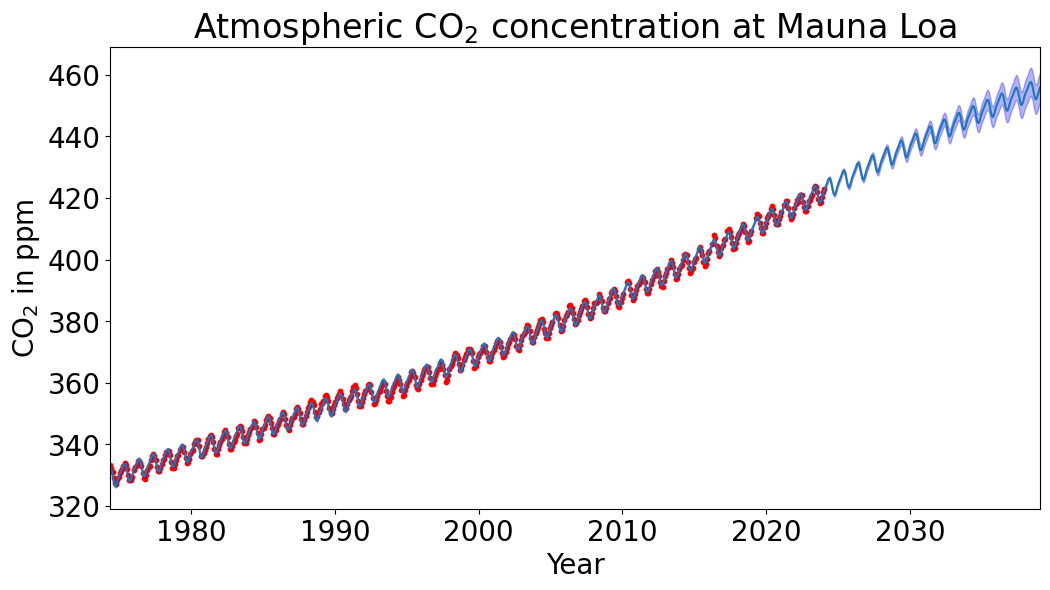

In [134]:
# Raising the noise_level to 0.1
# code here

k1 =66.0**2 * RBF(length_scale=10.0)  # long term smooth rising trend

k2 = ExpSineSquared(length_scale=1, periodicity=1, periodicity_bounds="fixed")
k3 = 1.0**2 * RBF(length_scale=10.0)

k4 = WhiteKernel(noise_level=0.1, noise_level_bounds=(1e-05, 100000.0))

kernel_gpml = k1 + k2*k3 + k4   # here we have just 1 kernel

gp = GaussianProcessRegressor(kernel=kernel_gpml, alpha=0.01,normalize_y=True)

# NOTE: running the .fit method will fit for the hyper parameters of the kernel. Fitting might take a while
X = np.array(newnew_tab['decimal date']).reshape(-1, 1)
y = np.array(newnew_tab.average)
gp.fit(X,y)

print("GPML kernel: %s" % gp.kernel_)
print("Log-marginal-likelihood: %.3f"
      % gp.log_marginal_likelihood(gp.kernel_.theta))

# code here
# plot the predictions

X_ = np.linspace(X.min(), X.max() + 15, 1000)[:, np.newaxis] # predict 10 years into the future
y_pred, y_std = gp.predict(X_, return_std=True)

# Illustration
plt.figure(figsize=(12,6))
plt.scatter(X, y, c='red',s=10)
plt.plot(X_, y_pred)
plt.fill_between(X_[:, 0], y_pred - y_std, y_pred + y_std,
                 alpha=0.3, color='blue')
plt.xlim(X_.min(), X_.max())
plt.xlabel("Year")
plt.ylabel(r"CO$_2$ in ppm")
plt.title(r"Atmospheric CO$_2$ concentration at Mauna Loa")

print("GPML kernel: %s" % gp.kernel_)
print("Log-marginal-likelihood: %.3f"
      % gp.log_marginal_likelihood(gp.kernel_.theta))

## Assessing the effects of COVID19 on CO2 levels

## Question 8 
(2 pts)

**First, without looking at the data, predict would happen to the CO2 levels in 2020 to recent times. Could the COVID19 pandemic affect these levels? Why or why not?**



Ther will be a drop at 2020-2021 (pandemic) since emission from travel/traffic is light in the overall trend.  The oscillation will still be there.

## Question 9
(2 pts)

**Now, go back and fit your GP model on data from up to 2019. Then, predict the CO2 levels in 2020 to the most recent year**

In [120]:
X = np.array(newnew_tab.loc[newnew_tab.year <2020]['decimal date']).reshape(-1, 1)
y = np.array(newnew_tab.loc[newnew_tab.year <2020].average)


In [121]:
# code here
# code here

k1 = 66.0**2 * RBF(length_scale=67.0)  # long term smooth rising trend

k2 = ExpSineSquared(length_scale=1, periodicity=1, periodicity_bounds="fixed")
k3 = 1.0**2 * RBF(length_scale=10.0)

k4 = WhiteKernel(noise_level=0.001, noise_level_bounds=(1e-05, 100000.0))

kernel_gpml = k1 + k2*k3 + k4   # here we have just 1 kernel

gp = GaussianProcessRegressor(kernel=kernel_gpml, alpha=0.01,normalize_y=True)

# NOTE: running the .fit method will fit for the hyper parameters of the kernel. Fitting might take a while
gp.fit(X,y)

print("GPML kernel: %s" % gp.kernel_)
print("Log-marginal-likelihood: %.3f"
      % gp.log_marginal_likelihood(gp.kernel_.theta))

GPML kernel: 3.36**2 * RBF(length_scale=40.5) + ExpSineSquared(length_scale=2.46, periodicity=1) * 0.265**2 * RBF(length_scale=9.01e+03) + WhiteKernel(noise_level=1e-05)
Log-marginal-likelihood: 689.832


/opt/conda/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


GPML kernel: 3.36**2 * RBF(length_scale=40.5) + ExpSineSquared(length_scale=2.46, periodicity=1) * 0.265**2 * RBF(length_scale=9.01e+03) + WhiteKernel(noise_level=1e-05)
Log-marginal-likelihood: 689.832


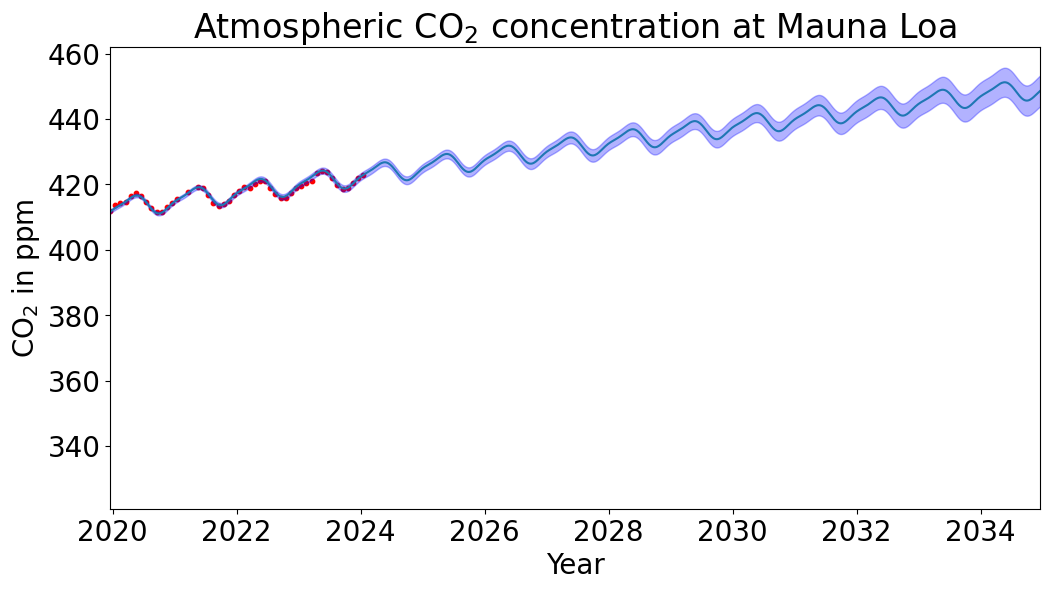

In [125]:
# code here
# plot the predictions

X_ = np.linspace(X.max(), X.max() + 15, 1000)[:, np.newaxis] # predict 10 years into the future
y_pred, y_std = gp.predict(X_, return_std=True)

# Illustration
plt.figure(figsize=(12,6))
X_known = np.array(newnew_tab['decimal date']).reshape(-1, 1)
y_known = np.array(newnew_tab.average)
plt.scatter(X_known, y_known, c='red',s=10)
plt.plot(X_, y_pred)
plt.fill_between(X_[:, 0], y_pred - y_std, y_pred + y_std,
                 alpha=0.3, color='blue')
plt.xlim(X_.min(), X_.max())
plt.xlabel("Year")
plt.ylabel(r"CO$_2$ in ppm")
plt.title(r"Atmospheric CO$_2$ concentration at Mauna Loa")

print("GPML kernel: %s" % gp.kernel_)
print("Log-marginal-likelihood: %.3f"
      % gp.log_marginal_likelihood(gp.kernel_.theta))

## Question 10
(3 pts)

**Describe whether what you found meets your expectations. Why or why not?**

The CO_2 level didn't drop to a noticeable level, different from my expectation.

## Part 7 Present solution


## Question 11
(4 pts)

**Discuss the model which appears to perform best: what kernels did you end up using? What are the hyperparameters of the best kernel?**

# your answer here

The RBF + exp sine kernel has log likelihood 757.292 while the fine-tuned one 757.819, which is slightly more confident.  
The current fine-tuned method mentioned above looks to perform already very well.

## Part 8  Launch, Monitor and Maintain

Nothing to here for this lab. 



**All done! Nice job!**